# Example for consensus
This notebook demonstrates how the multiplicative weights algorithm can enhance the robustness of a consensus algorithm against Byzantine attacks.

## 1. Set some global parameters:

In [34]:
from multiprocessing import Pool
from numpy import float64
from numpy.typing import NDArray

if __name__ == "__main__":
    N_STATE = 3
    N_ITER = 50
    ALPHA = 0.35

    NORMAL_LB = -100.0  # Lower bound of normal nodes' initial state values
    NORMAL_UB = 100.0  # Upper bound of normal nodes' initial state values

## 2. Define the graph topology and characterize the behavior of Byzantine nodes.
### (1) Define the graph

We consider a simple network consisting of:

- Five **normal nodes** arranged in a **ring topology**, ensuring full connectivity among themselves. We denote the set of normal nodes as 
$$
\mathcal{I}_\text{normal} = \{1, 2, 3, 4, 5\}.
$$

- Two **Byzantine nodes**, labeled 6 and 7, denoted as
$$
\mathcal{I}_\text{Byz} = \{6, 7, 8, 9, 10\}.
$$
Node 6 is connected to node 1, and node 7 is connected to node 2, simulating malicious or faulty behavior.

Let the **entire set of nodes** be
$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz} = \{1, 2, 3, 4, 5, 6, 7, 8, 9, 10\}.
$$

The **adjacency relationships** can be summarized as:

- Ring connections among normal nodes: $1 \leftrightarrow 2 \leftrightarrow 3 \leftrightarrow 4 \leftrightarrow 5 \leftrightarrow 1$  
- Byzantine connections: $6 \leftrightarrow 1$, $7 \leftrightarrow 2$, $8 \leftrightarrow 3$, $9 \leftrightarrow 4$, $10 \leftrightarrow 5$

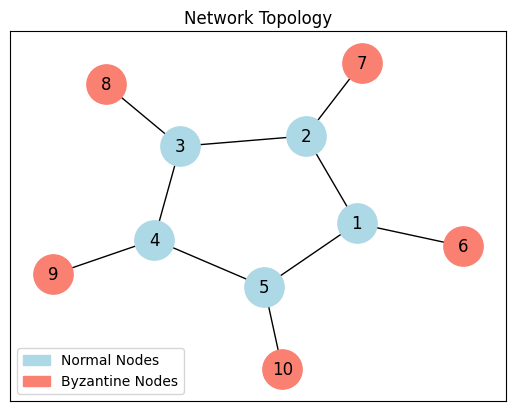

In [2]:
def graph_server(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [("1", "2"), ("2", "3"), ("3", "4"), ("4", "5"), ("5", "1")]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
    BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("5", "10")]
    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()
    ax.set_title("Network Topology")

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

### (2) Define the behavior of Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i^t$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
$$
x_i^{t + 1} = x_i^t
$$

2. **Update state randomly:**
$$
x_i^{t + 1} \sim \mathcal{U}(a, b)
$$
where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

In [35]:
def byzantine_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    type: str,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Byzantine behavior: do not follow the consensus algorithm
        laplacian = nh.laplacian(states[k])
        # Keep the state unchanged
        if type == "constant":
            states[k + 1] = states[k]
        elif type == "random":
            states[k + 1] = uniform(lower_bound, upper_bound, n_state)
        elif type == "normal":
            states[k + 1] = states[k] - laplacian * alpha

    return states


if __name__ == "__main__":
    BYZ_TYPE = "constant"  # Byzantine attack type: "constant", "random", "normal"
    BYZ_LB = 500.0  # Lower bound of Byzantine nodes' state values
    BYZ_UB = 600.0  # Upper bound of Byzantine nodes' state values

## 3. Execute a standard consensus algorithm

In our system, we use the consensus iteration to update the states of nodes. Let the global state vector of all nodes at iteration $k$ be denoted as $X^k \in \mathbb{R}^{nd}$, where $n$ is the number of nodes and $d$ is the dimension of each node's state. The consensus iteration is given by:

$$
X^{k + 1} = X^k - \alpha (L \otimes I_d) X^k,
$$

where:  

- $L \in \mathbb{R}^{n \times n}$ is the **graph Laplacian matrix**, defined as $L = D - A$, with $A$ being the adjacency matrix of the network and $D$ the degree matrix.  
- $I_d \in \mathbb{R}^{d \times d}$ is the **identity matrix**, allowing the Laplacian to act independently on each dimension of the state.  
- $\otimes$ denotes the **Kronecker product**, which expands the Laplacian to operate on the multi-dimensional state vector.  
- $\alpha > 0$ is the **step size** or **learning rate**, controlling how much each node adjusts its state in each iteration.

### (1) Run the algorithm

In [36]:
def baseline_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        states[k + 1] = states[k] - nh.laplacian(states[k]) * alpha

    return states


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        baseline_nodes = {
            i: pool.apply_async(
                baseline_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        baseline_states = {i: node.get() for i, node in baseline_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:43659
INFO:topolink.discovery:Registered graph service with name default
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:36681.
INFO:topolink.graph:Node '10' joined graph 'default' from 172.26.120.171:45127.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:38317.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:34001.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:42285.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:46539.
INFO:topolink.graph:Node '8' joined graph 'default' from 172.26.120.171:45081.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:44111.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:38233.
INFO:topolink.graph:Node '9' joined graph 'default' from 172.26.120.171:42339.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.

### (2) Visualize the Results

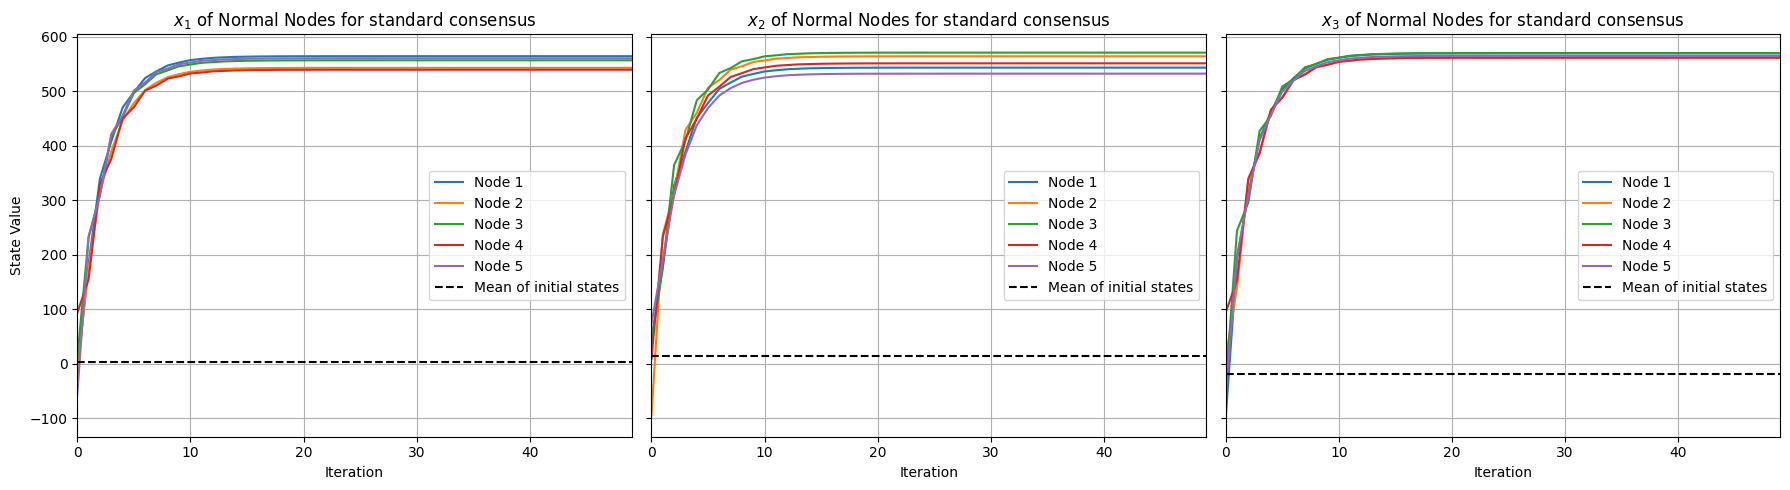

In [37]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax1: Sequence[Axes]
    fig1, ax1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = baseline_states[i]
        for j in range(N_STATE):
            (line,) = ax1[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [baseline_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax1[j].axhline(
            mean_states[j],
            color="k",
            linestyle="--",
            label="Mean of initial states",
        )

    for j in range(N_STATE):
        ax1[j].set_xlabel("Iteration")
        ax1[j].set_xlim(0, N_ITER - 1)
        ax1[j].legend()
        ax1[j].set_title(f"$x_{j + 1}$ of Normal Nodes for standard consensus")
        ax1[j].grid()

    ax1[0].set_ylabel("State Value")

    fig1.tight_layout()

## 4. Execute a Multiplicative Weights based consensus algorithm
### (1) Multiplicative Weights algorithm

---

For $n$ experts, each expert $i$ is assigned a weight $\omega_i^t$ at time step $t$.
When expert $i$ produces outcome $j^t$, it incurs a penalty $M(i, j^t)$.
The weight of expert $i$ is then updated according to:

$$
\omega_i^{t + 1} = \omega_i^t (1 - \epsilon M(i, j^t))
$$

where $\epsilon$ is a learning rate parameter.

> **Note**
> The following notation is independent of the above; the above was written according to the original paper.

---

For the consensus algorithm, we define the penalty as

$$
M(x_j^t) = \sum_{v \in \mathcal{N}_i} \frac{|| x_j^t - x_v^t ||}{d_i}
$$

where $x_j^t$ denotes the state received from neighbor $j$, $\mathcal{N}_i$ denotes the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$


To update the local state $x_i^t$, we derive a reasonable estimate $\hat{x}_i$ based on the neighbors’ states as

$$
x_i^{t + 1} = (1 - \alpha) x_i^t + \alpha \hat{x}_i^t
$$

where $\alpha \in [0, 1]$ is a weighting factor.
We consider two approaches to derive this estimate:

1) **Neighbor-based selection:**
At each time step $t$, node $i$ selects a neighbor $j$ with probability $p_j^t$ and uses its state $x_j^t$ as the estimate $\hat{x}_i^t$, where

$$
p_j^t = \frac{\omega_j^t}{\sum_{k \in \mathcal{N}_i} \omega_k^t}.
$$

2) **Weighted average:**
At each time step $t$, the estimate is obtained as a weighted average 

$$
\hat{x}_{i}^t = \frac{\sum_{j \in \mathcal{N_i}} \omega_j^t x_j^t}{\sum_{j \in \mathcal{N_i}} \omega_j^t}.
$$

---

In [38]:
from typing import Callable

PenaltyFunc = Callable[[str, dict[str, NDArray[float64]]], float]

from abc import ABCMeta, abstractmethod
from typing import Type


class MultiplicativeWeights(metaclass=ABCMeta):
    _name: str
    _registry: dict[str, Type["MultiplicativeWeights"]] = {}

    def __init_subclass__(cls, **kwargs) -> None:
        super().__init_subclass__(**kwargs)
        cls._registry[cls._name] = cls

    def __init__(
        self, experts: list[str], penalty_func: PenaltyFunc, eps: float
    ) -> None:
        self.experts = experts
        self.eps = eps
        self.weights = {j: 1.0 for j in experts}
        self.penalty_func = penalty_func

    @classmethod
    def create(cls, name: str, *args, **kwargs) -> "MultiplicativeWeights":
        if name not in cls._registry:
            raise ValueError(f"Unknown MW type: {name}")
        return cls._registry[name](*args, **kwargs)

    def update(self, outcomes: dict[str, NDArray[float64]]) -> None:
        for j in self.experts:
            penalty = self.penalty_func(j, outcomes)
            factor = 1 - self.eps * penalty
            if factor < 0:
                self.eps = 1 / penalty * 0.99
                factor = 1 - self.eps * penalty
            self.weights[j] *= factor

    @abstractmethod
    def make_prediction(
        self, outcomes: dict[str, NDArray[float64]]
    ) -> NDArray[float64]: ...


class ProbabilisticMW(MultiplicativeWeights):
    _name: str = "probabilistic"

    @property
    def probabilities(self) -> NDArray[float64]:
        from numpy import array

        probs = array([self.weights[j] for j in self.experts])
        return probs / probs.sum()

    def choose_expert(self) -> str:
        from numpy.random import choice

        probs = self.probabilities
        return choice(self.experts, p=probs)

    def make_prediction(
        self, outcomes: dict[str, NDArray[float64]]
    ) -> NDArray[float64]:
        expert_choice = self.choose_expert()
        return outcomes[expert_choice]


class CombinedMW(MultiplicativeWeights):
    _name: str = "combined"

    def combine_outcomes(
        self, outcomes: dict[str, NDArray[float64]]
    ) -> NDArray[float64]:
        from numpy import average

        weights_ = [self.weights[j] for j in self.experts]
        outcomes_ = [outcomes[j] for j in self.experts]
        weighted_avg = average(outcomes_, axis=0, weights=weights_)

        return weighted_avg

    def make_prediction(
        self, outcomes: dict[str, NDArray[float64]]
    ) -> NDArray[float64]:
        return self.combine_outcomes(outcomes)

### (2) Run the algorithm

In [71]:
def mw_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
    type: str,
) -> NDArray[float64]:
    from numpy import zeros, mean
    from numpy.linalg import norm
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    def penalty_func(j: str, x_js: dict[str, NDArray[float64]]) -> float:
        return mean(
            [norm(x_js[j] - x_js[neighbor]) for neighbor in nh.neighbor_names],
            dtype=float64,
        )

    nh = NodeHandle(name)
    mw = MultiplicativeWeights.create(type, nh.neighbor_names, penalty_func, 0.002)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Update state
        nh.broadcast(states[k])
        state_js = nh.gather()

        states[k + 1] = (1 - alpha) * states[k] + alpha * mw.make_prediction(state_js)

        # Update weights
        mw.update(state_js)

    return states


if __name__ == "__main__":
    MW_TYPE = "probabilistic"  # MW algorithm type: "combined" or "probabilistic"

    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        mw_nodes = {
            i: pool.apply_async(
                mw_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB, MW_TYPE)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        mw_states = {i: node.get() for i, node in mw_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:33403
INFO:topolink.discovery:Registered graph service with name default
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:32917.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:43109.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:44757.
INFO:topolink.graph:Node '10' joined graph 'default' from 172.26.120.171:34023.
INFO:topolink.graph:Node '9' joined graph 'default' from 172.26.120.171:43637.
INFO:topolink.graph:Node '8' joined graph 'default' from 172.26.120.171:38889.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:32983.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:40905.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:46249.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:37655.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.

### (3) Visualize the Results

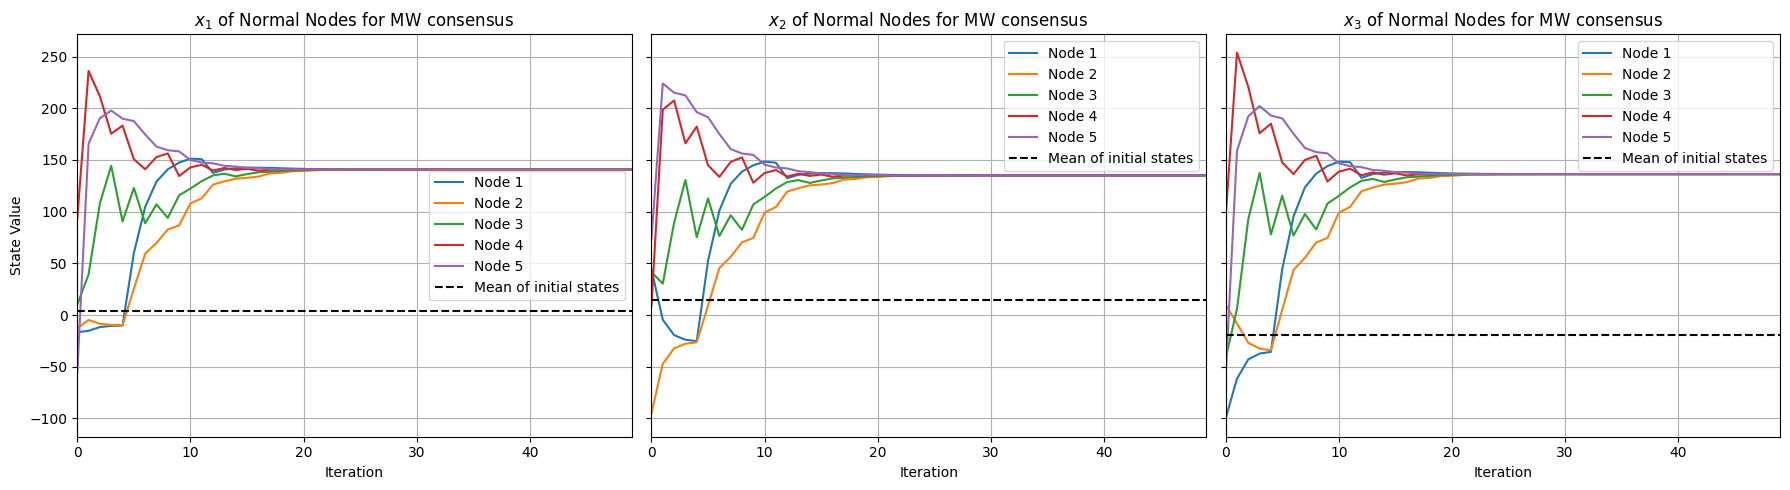

In [72]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax2: Sequence[Axes]
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = mw_states[i]
        for j in range(N_STATE):
            (line,) = ax2[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [mw_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax2[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial states"
        )

    for j in range(N_STATE):
        ax2[j].set_xlabel("Iteration")
        ax2[j].set_xlim(0, N_ITER - 1)
        ax2[j].legend()
        ax2[j].set_title(f"$x_{j + 1}$ of Normal Nodes for MW consensus")
        ax2[j].grid()

    ax2[0].set_ylabel("State Value")

    fig2.tight_layout()

## 5. Byzantine type

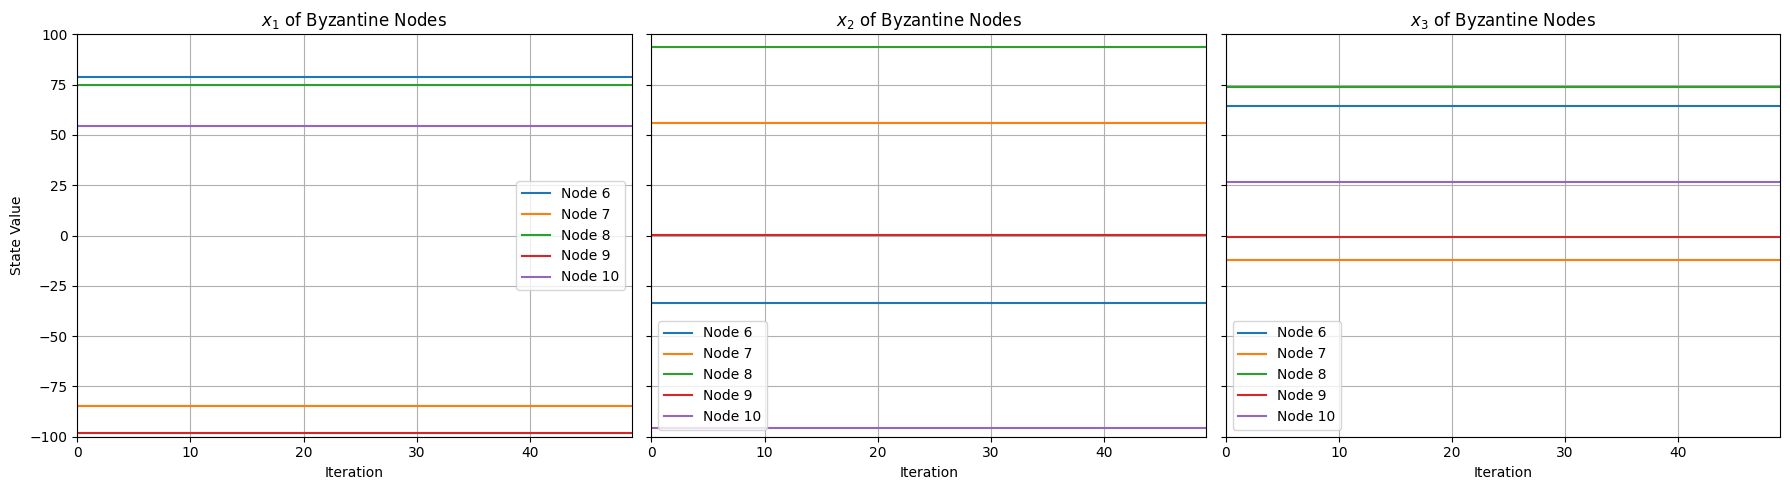

In [9]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax3: Sequence[Axes]
    fig3, ax3 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in BYZANTINE_NODES:
        states = byzantine_states[i]
        for j in range(N_STATE):
            (line,) = ax3[j].plot(states[:, j])
            line.set_label(f"Node {i}")

    ax3[0].set_ylabel("State Value")
    ax3[0].set_ylim(BYZ_LB, BYZ_UB)
    for j in range(N_STATE):
        ax3[j].set_xlabel("Iteration")
        ax3[j].set_xlim(0, N_ITER - 1)
        ax3[j].legend()
        ax3[j].set_title(f"$x_{j + 1}$ of Byzantine Nodes")
        ax3[j].grid()

    fig3.tight_layout()